In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV ,train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.pipeline import Pipeline


In [3]:
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing()

In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price']=data.target

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.shape

(20640, 9)

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

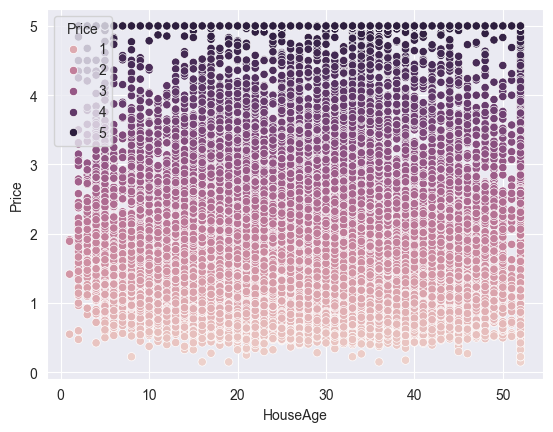

In [10]:
sns.scatterplot(x=df['HouseAge'] , y=df['Price'], hue=df['Price'])
plt.show()

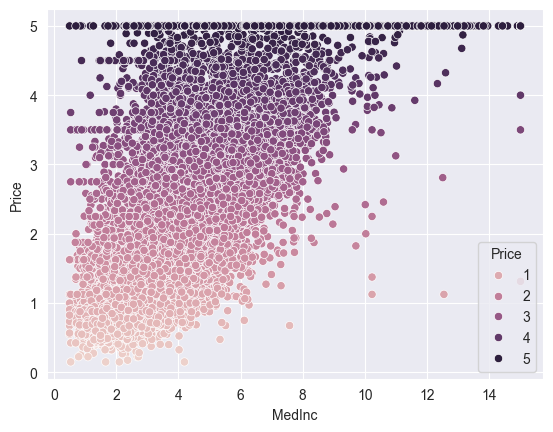

In [11]:
sns.scatterplot(x=df['MedInc'] , y=df['Price'], hue=df['Price'])
plt.show()

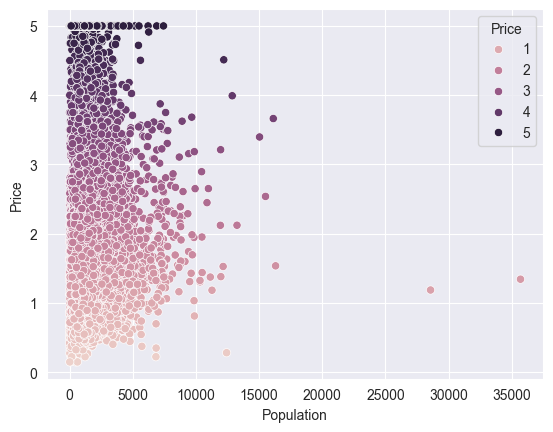

In [12]:
sns.scatterplot(x=df['Population'] , y=df['Price'], hue=df['Price'])
plt.show()

In [13]:
X=data.data
y=data.target

In [14]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=15)

In [15]:
#Hyperparameter Tunning
params = {
'max_depth': [3, 4, 5, 6, 8, None],
'min_samples_split': [10, 20, 40,80],
'min_samples_leaf': [5, 10, 20]
}

In [16]:
model=DecisionTreeRegressor()

In [17]:
grid_search=GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [18]:
import warnings
warnings.filterwarnings('ignore')
grid_search.fit(X_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_leaf': [5, 10, ...], 'min_samples_split': [10, 20, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [19]:
grid_search.best_params_

{'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 20}

In [20]:
grid_search.best_score_

np.float64(0.7279111791915357)

In [21]:
y_pred=grid_search.predict(X_test)

In [22]:
r2_score(y_test,y_pred)

0.7235029683464713

In [23]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.4035514466771682
0.36765982203446956


In [24]:
best_estimater=grid_search.best_estimator_

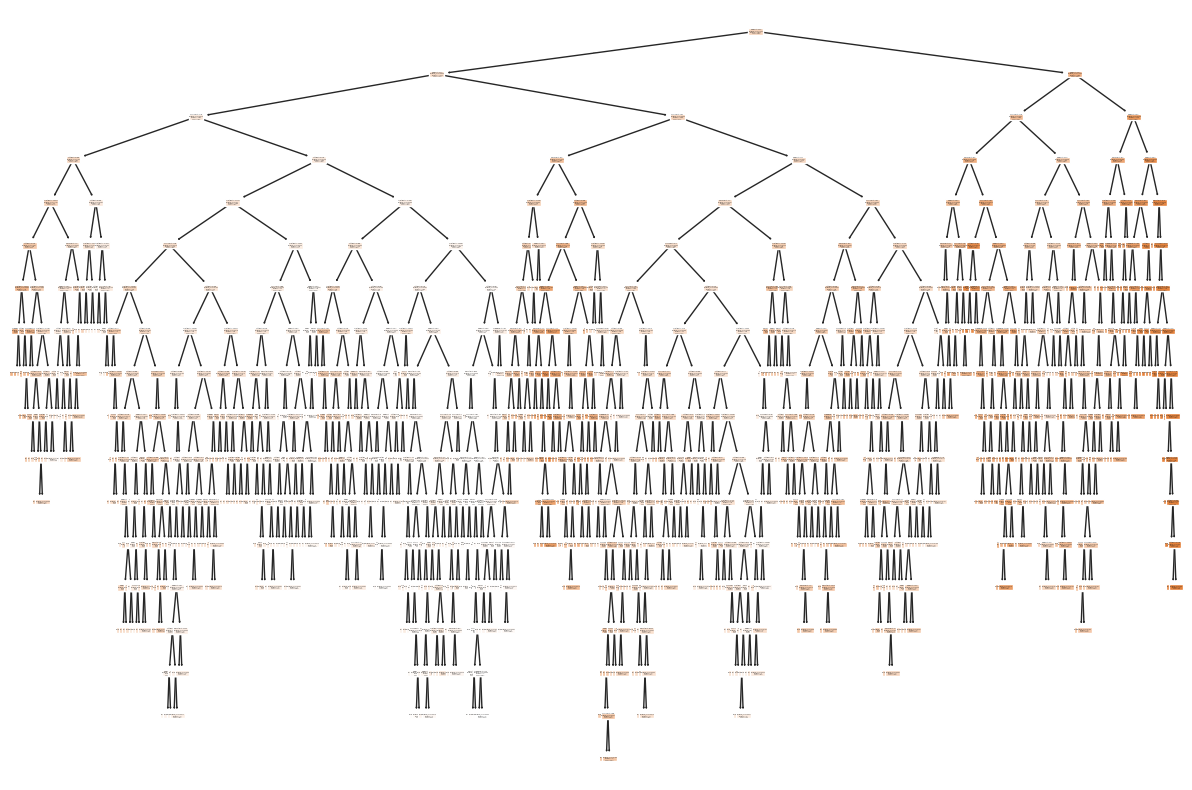

In [25]:
from sklearn import tree
column_names=['MedInc','HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']
plt.figure(figsize=(15,10))
tree.plot_tree(best_estimater,feature_names=column_names,filled=True)
plt.show()
